In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

In [2]:
class EvaluationMetrics:
    """
    Binary classification evaluation metrics from scratch
    """
    
    def __init__(self, y_true, y_pred):
        """
        Initialize with true labels and predictions
        
        Parameters:
        -----------
        y_true : torch.Tensor
            True labels (0 or 1)
        y_pred : torch.Tensor
            Predicted labels (0 or 1)
        """
        self.y_true = y_true.long()
        self.y_pred = y_pred.long()
        
        # Compute confusion matrix components
        self.tp = ((self.y_true == 1) & (self.y_pred == 1)).sum().item()
        self.tn = ((self.y_true == 0) & (self.y_pred == 0)).sum().item()
        self.fp = ((self.y_true == 0) & (self.y_pred == 1)).sum().item()
        self.fn = ((self.y_true == 1) & (self.y_pred == 0)).sum().item()
        
        self.n = len(y_true)
    
    def confusion_matrix(self):
        """
        Return confusion matrix as 2x2 tensor
        [[TN, FP],
         [FN, TP]]
        """
        return torch.tensor([[self.tn, self.fp],
                            [self.fn, self.tp]])
    
    def accuracy(self):
        """
        Accuracy = (TP + TN) / (TP + TN + FP + FN)
        
        Proportion of correct predictions
        """
        return (self.tp + self.tn) / self.n
    
    def precision(self):
        """
        Precision = TP / (TP + FP)
        
        Of all positive predictions, how many were correct?
        Also called Positive Predictive Value (PPV)
        """
        if (self.tp + self.fp) == 0:
            return 0.0
        return self.tp / (self.tp + self.fp)
    
    def recall(self):
        """
        Recall = TP / (TP + FN)
        
        Of all actual positives, how many did we catch?
        Also called Sensitivity, True Positive Rate (TPR), Hit Rate
        """
        if (self.tp + self.fn) == 0:
            return 0.0
        return self.tp / (self.tp + self.fn)
    
    def f1_score(self):
        """
        F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
        
        Harmonic mean of precision and recall
        Balances both metrics
        """
        prec = self.precision()
        rec = self.recall()
        if (prec + rec) == 0:
            return 0.0
        return 2 * (prec * rec) / (prec + rec)
    
    def specificity(self):
        """
        Specificity = TN / (TN + FP)
        
        Of all actual negatives, how many did we correctly identify?
        Also called True Negative Rate (TNR), Selectivity
        """
        if (self.tn + self.fp) == 0:
            return 0.0
        return self.tn / (self.tn + self.fp)
    
    def false_positive_rate(self):
        """
        False Positive Rate = FP / (FP + TN)
        
        Of all actual negatives, how many did we wrongly classify as positive?
        Also called Fall-out, Type I error rate
        FPR = 1 - Specificity
        """
        return 1 - self.specificity()
    
    def false_negative_rate(self):
        """
        False Negative Rate = FN / (FN + TP)
        
        Of all actual positives, how many did we miss?
        Also called Miss Rate, Type II error rate
        FNR = 1 - Recall
        """
        return 1 - self.recall()
    
    def true_negative_rate(self):
        """
        True Negative Rate = TN / (TN + FP)
        
        Same as Specificity
        """
        return self.specificity()
    
    def summary(self):
        """
        Print comprehensive summary of all metrics
        """
        print("=" * 70)
        print("EVALUATION METRICS SUMMARY")
        print("=" * 70)
        
        print(f"\nTotal Samples: {self.n}")
        print(f"Actual Positives: {self.tp + self.fn} ({(self.tp + self.fn)/self.n*100:.1f}%)")
        print(f"Actual Negatives: {self.tn + self.fp} ({(self.tn + self.fp)/self.n*100:.1f}%)")
        
        print("\n" + "-" * 70)
        print("CONFUSION MATRIX COMPONENTS")
        print("-" * 70)
        print(f"True Positives (TP):  {self.tp}")
        print(f"True Negatives (TN):  {self.tn}")
        print(f"False Positives (FP): {self.fp} (Type I Error)")
        print(f"False Negatives (FN): {self.fn} (Type II Error)")
        
        print("\n" + "-" * 70)
        print("MAIN METRICS")
        print("-" * 70)
        print(f"Accuracy:    {self.accuracy():.4f} ({self.accuracy()*100:.2f}%)")
        print(f"Precision:   {self.precision():.4f} ({self.precision()*100:.2f}%)")
        print(f"Recall:      {self.recall():.4f} ({self.recall()*100:.2f}%)")
        print(f"F1 Score:    {self.f1_score():.4f} ({self.f1_score()*100:.2f}%)")
        
        print("\n" + "-" * 70)
        print("ADDITIONAL METRICS")
        print("-" * 70)
        print(f"Specificity (TNR):        {self.specificity():.4f} ({self.specificity()*100:.2f}%)")
        print(f"False Positive Rate:      {self.false_positive_rate():.4f} ({self.false_positive_rate()*100:.2f}%)")
        print(f"False Negative Rate:      {self.false_negative_rate():.4f} ({self.false_negative_rate()*100:.2f}%)")
        
        print("\n" + "=" * 70)
    
    def plot_confusion_matrix(self, title="Confusion Matrix"):
        """
        Visualize confusion matrix as heatmap
        """
        cm = self.confusion_matrix().numpy()
        
        plt.figure(figsize=(8, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Predicted Negative', 'Predicted Positive'],
                   yticklabels=['Actual Negative', 'Actual Positive'],
                   cbar_kws={'label': 'Count'},
                   linewidths=2, linecolor='black',
                   annot_kws={'size': 16, 'weight': 'bold'})
        
        # Add labels
        plt.text(0.5, 0.25, f'TN\n{self.tn}', ha='center', va='center', 
                fontsize=12, color='darkblue', weight='bold')
        plt.text(1.5, 0.25, f'FP\n{self.fp}', ha='center', va='center', 
                fontsize=12, color='darkred', weight='bold')
        plt.text(0.5, 1.25, f'FN\n{self.fn}', ha='center', va='center', 
                fontsize=12, color='darkred', weight='bold')
        plt.text(1.5, 1.25, f'TP\n{self.tp}', ha='center', va='center', 
                fontsize=12, color='darkgreen', weight='bold')
        
        plt.title(title, fontsize=14, fontweight='bold', pad=20)
        plt.ylabel('True Label', fontsize=12, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def plot_metrics_bar(self):
        """
        Visualize all metrics as bar chart
        """
        metrics = {
            'Accuracy': self.accuracy(),
            'Precision': self.precision(),
            'Recall': self.recall(),
            'F1 Score': self.f1_score(),
            'Specificity': self.specificity(),
            'FP Rate': self.false_positive_rate(),
            'FN Rate': self.false_negative_rate()
        }
        
        names = list(metrics.keys())
        values = list(metrics.values())
        
        # Color code: green for good metrics, red for error rates
        colors = ['green', 'blue', 'blue', 'purple', 'cyan', 'red', 'red']
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(names, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{value:.3f}\n({value*100:.1f}%)',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.ylim(0, 1.1)
        plt.ylabel('Score', fontsize=12, fontweight='bold')
        plt.title('Classification Metrics Overview', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()

In [3]:
print("=" * 70)
print("EXAMPLE 1: BALANCED DATASET")
print("=" * 70)

# Simulate predictions on balanced dataset
y_true_balanced = torch.tensor([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0])
y_pred_balanced = torch.tensor([1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0])

print(f"\nTrue labels:      {y_true_balanced.tolist()}")
print(f"Predicted labels: {y_pred_balanced.tolist()}")
print(f"\nDataset size: {len(y_true_balanced)}")
print(f"Positive samples: {(y_true_balanced == 1).sum().item()}")
print(f"Negative samples: {(y_true_balanced == 0).sum().item()}")

# Compute metrics
metrics_balanced = EvaluationMetrics(y_true_balanced, y_pred_balanced)
print("\n")
metrics_balanced.summary()

EXAMPLE 1: BALANCED DATASET

True labels:      [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0]
Predicted labels: [1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0]

Dataset size: 20
Positive samples: 10
Negative samples: 10


EVALUATION METRICS SUMMARY

Total Samples: 20
Actual Positives: 10 (50.0%)
Actual Negatives: 10 (50.0%)

----------------------------------------------------------------------
CONFUSION MATRIX COMPONENTS
----------------------------------------------------------------------
True Positives (TP):  8
True Negatives (TN):  8
False Positives (FP): 2 (Type I Error)
False Negatives (FN): 2 (Type II Error)

----------------------------------------------------------------------
MAIN METRICS
----------------------------------------------------------------------
Accuracy:    0.8000 (80.00%)
Precision:   0.8000 (80.00%)
Recall:      0.8000 (80.00%)
F1 Score:    0.8000 (80.00%)

----------------------------------------------------------------------
ADDIT

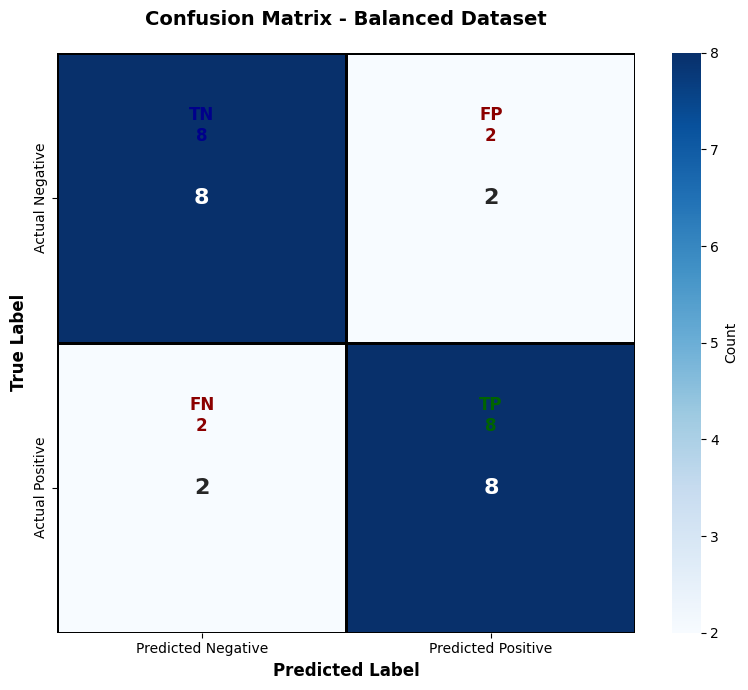

In [4]:
# Visualize confusion matrix
metrics_balanced.plot_confusion_matrix("Confusion Matrix - Balanced Dataset")

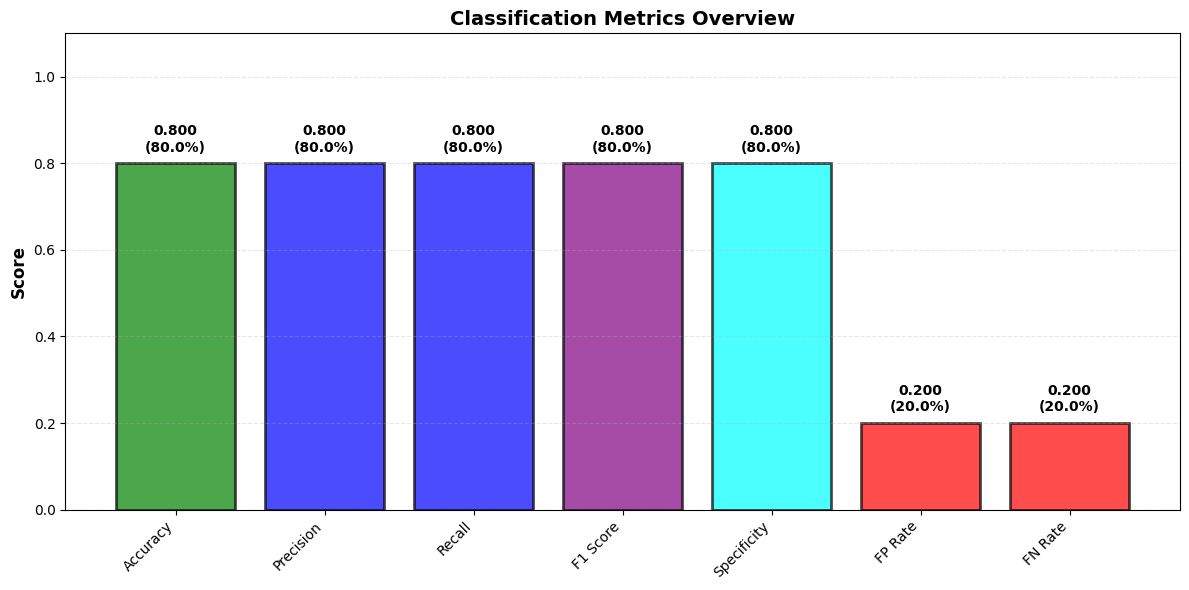

In [5]:
# Visualize metrics
metrics_balanced.plot_metrics_bar()

In [6]:
print("=" * 70)
print("EXAMPLE 2: IMBALANCED DATASET (5% Positive Rate)")
print("=" * 70)

# Simulate rare disease: 95% healthy, 5% sick
n_samples = 100
n_positive = 5
n_negative = 95

# True labels
y_true_imbalanced = torch.cat([torch.ones(n_positive), torch.zeros(n_negative)]).long()

# Simulate a good model that catches most diseases but has some false positives
y_pred_imbalanced = y_true_imbalanced.clone()
# Catch 4 out of 5 diseases (80% recall)
y_pred_imbalanced[0] = 0  # Miss 1 disease (FN)
# 3 false alarms out of 95 healthy (3.2% FPR)
y_pred_imbalanced[10] = 1  # FP
y_pred_imbalanced[20] = 1  # FP
y_pred_imbalanced[30] = 1  # FP

print(f"\nDataset size: {n_samples}")
print(f"Positive (sick): {n_positive} ({n_positive/n_samples*100:.1f}%)")
print(f"Negative (healthy): {n_negative} ({n_negative/n_samples*100:.1f}%)")

metrics_imbalanced = EvaluationMetrics(y_true_imbalanced, y_pred_imbalanced)
print("\n")
metrics_imbalanced.summary()

print("\n" + "=" * 70)
print("INTERPRETATION FOR RARE DISEASE DETECTION")
print("=" * 70)
print(f"Accuracy is {metrics_imbalanced.accuracy()*100:.1f}% - sounds good!")
print(f"But we missed {metrics_imbalanced.fn} disease case(s) (FN)")
print(f"Recall (sensitivity) is more important: {metrics_imbalanced.recall()*100:.1f}%")
print(f"We want high recall to catch all diseases, even with some false alarms.")

EXAMPLE 2: IMBALANCED DATASET (5% Positive Rate)

Dataset size: 100
Positive (sick): 5 (5.0%)
Negative (healthy): 95 (95.0%)


EVALUATION METRICS SUMMARY

Total Samples: 100
Actual Positives: 5 (5.0%)
Actual Negatives: 95 (95.0%)

----------------------------------------------------------------------
CONFUSION MATRIX COMPONENTS
----------------------------------------------------------------------
True Positives (TP):  4
True Negatives (TN):  92
False Positives (FP): 3 (Type I Error)
False Negatives (FN): 1 (Type II Error)

----------------------------------------------------------------------
MAIN METRICS
----------------------------------------------------------------------
Accuracy:    0.9600 (96.00%)
Precision:   0.5714 (57.14%)
Recall:      0.8000 (80.00%)
F1 Score:    0.6667 (66.67%)

----------------------------------------------------------------------
ADDITIONAL METRICS
----------------------------------------------------------------------
Specificity (TNR):        0.9684 (96.

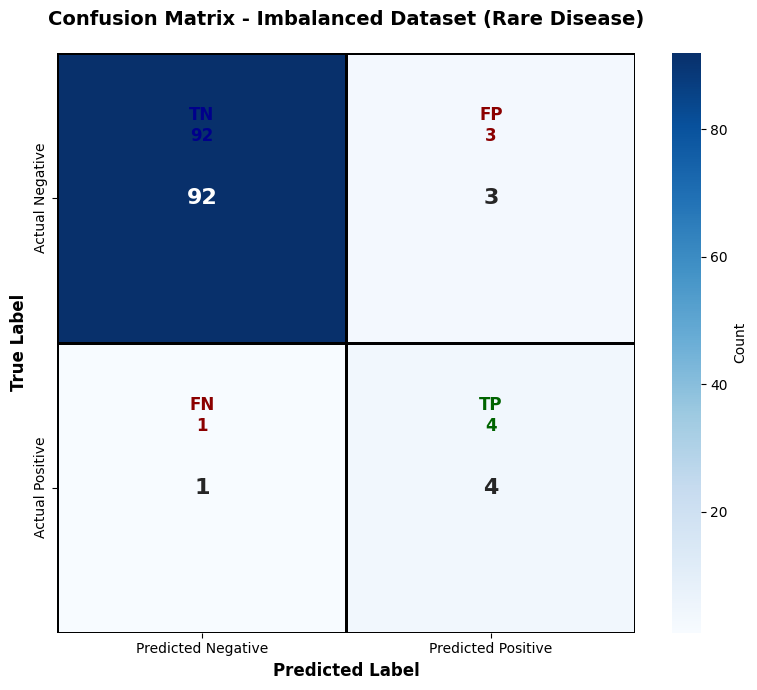

In [7]:
metrics_imbalanced.plot_confusion_matrix("Confusion Matrix - Imbalanced Dataset (Rare Disease)")

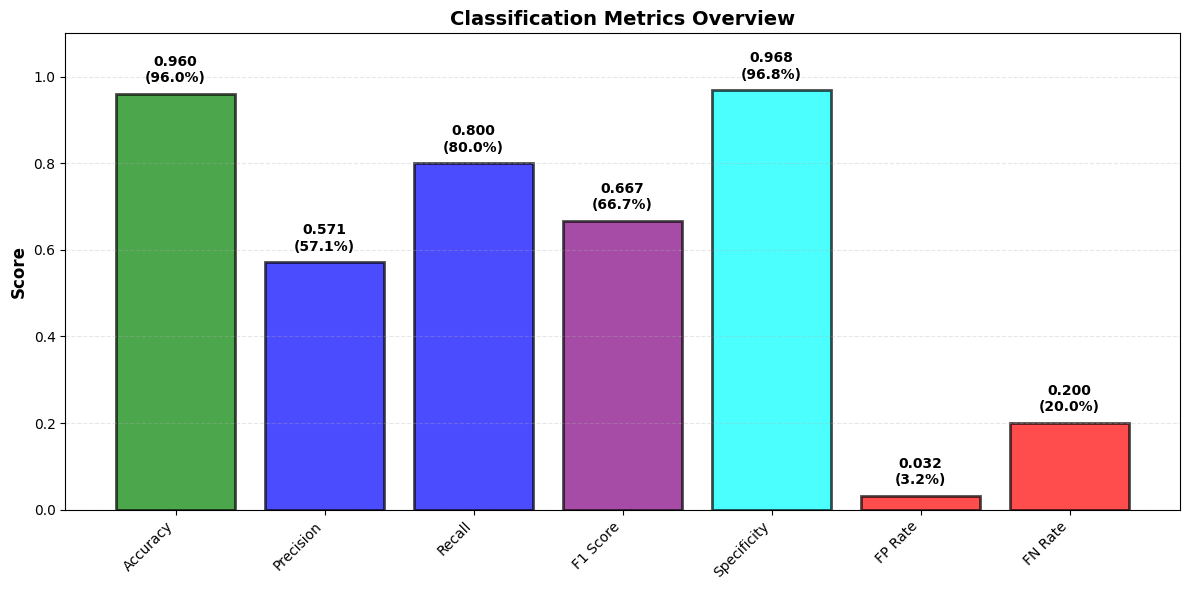

In [8]:
metrics_imbalanced.plot_metrics_bar()

In [9]:
print("=" * 70)
print("EXAMPLE 3: SPAM DETECTION (High Precision Needed)")
print("=" * 70)

# 30% spam, 70% legitimate
n_samples = 100
n_spam = 30
n_legit = 70

y_true_spam = torch.cat([torch.ones(n_spam), torch.zeros(n_legit)]).long()

# Conservative model: only flag obvious spam to avoid FP
y_pred_spam = y_true_spam.clone()
# Catch 70% of spam (21 out of 30)
for i in range(9):
    y_pred_spam[i] = 0  # Miss some spam (FN)
# Very few false positives (only 1 legitimate email marked as spam)
y_pred_spam[40] = 1  # FP

print(f"\nDataset size: {n_samples}")
print(f"Spam: {n_spam} ({n_spam/n_samples*100:.1f}%)")
print(f"Legitimate: {n_legit} ({n_legit/n_samples*100:.1f}%)")

metrics_spam = EvaluationMetrics(y_true_spam, y_pred_spam)
print("\n")
metrics_spam.summary()

print("\n" + "=" * 70)
print("INTERPRETATION FOR SPAM DETECTION")
print("=" * 70)
print(f"Precision is {metrics_spam.precision()*100:.1f}% - very high!")
print(f"Only {metrics_spam.fp} legitimate email(s) marked as spam (good!)")
print(f"Recall is {metrics_spam.recall()*100:.1f}% - some spam gets through")
print(f"Trade-off: Better to let some spam through than block important emails.")

EXAMPLE 3: SPAM DETECTION (High Precision Needed)

Dataset size: 100
Spam: 30 (30.0%)
Legitimate: 70 (70.0%)


EVALUATION METRICS SUMMARY

Total Samples: 100
Actual Positives: 30 (30.0%)
Actual Negatives: 70 (70.0%)

----------------------------------------------------------------------
CONFUSION MATRIX COMPONENTS
----------------------------------------------------------------------
True Positives (TP):  21
True Negatives (TN):  69
False Positives (FP): 1 (Type I Error)
False Negatives (FN): 9 (Type II Error)

----------------------------------------------------------------------
MAIN METRICS
----------------------------------------------------------------------
Accuracy:    0.9000 (90.00%)
Precision:   0.9545 (95.45%)
Recall:      0.7000 (70.00%)
F1 Score:    0.8077 (80.77%)

----------------------------------------------------------------------
ADDITIONAL METRICS
----------------------------------------------------------------------
Specificity (TNR):        0.9857 (98.57%)
False Po

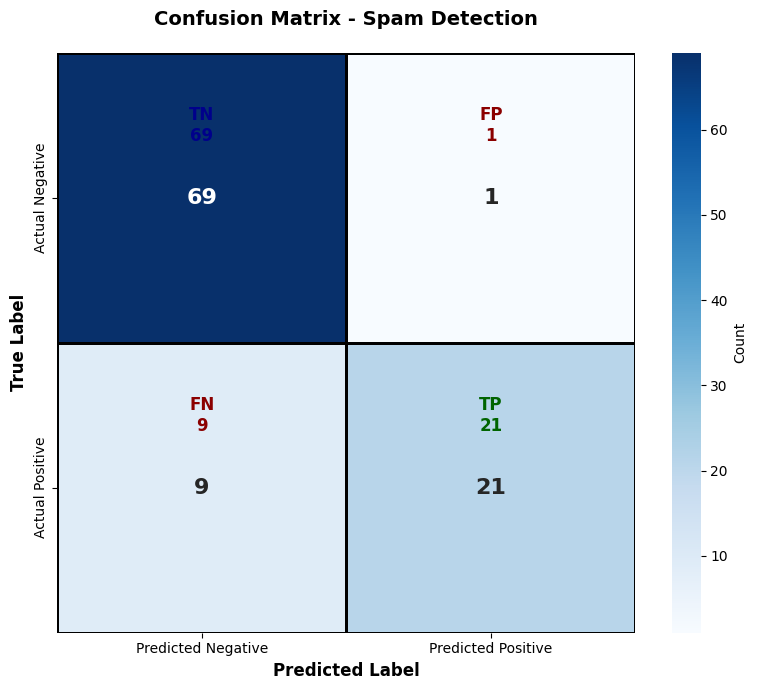

In [10]:
metrics_spam.plot_confusion_matrix("Confusion Matrix - Spam Detection")

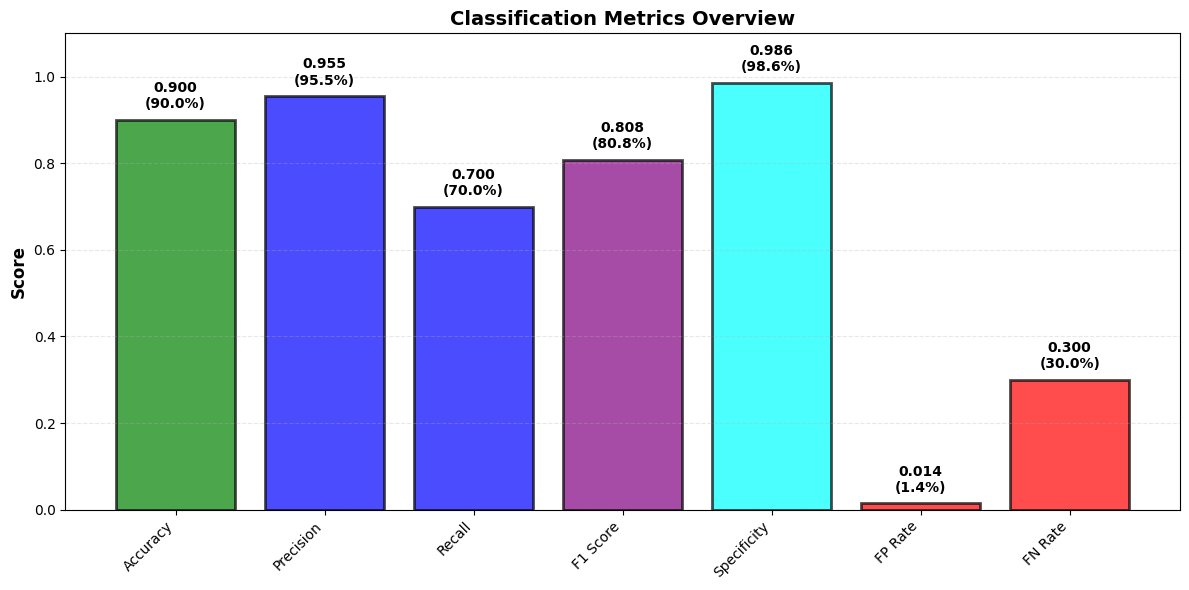

In [11]:
metrics_spam.plot_metrics_bar()

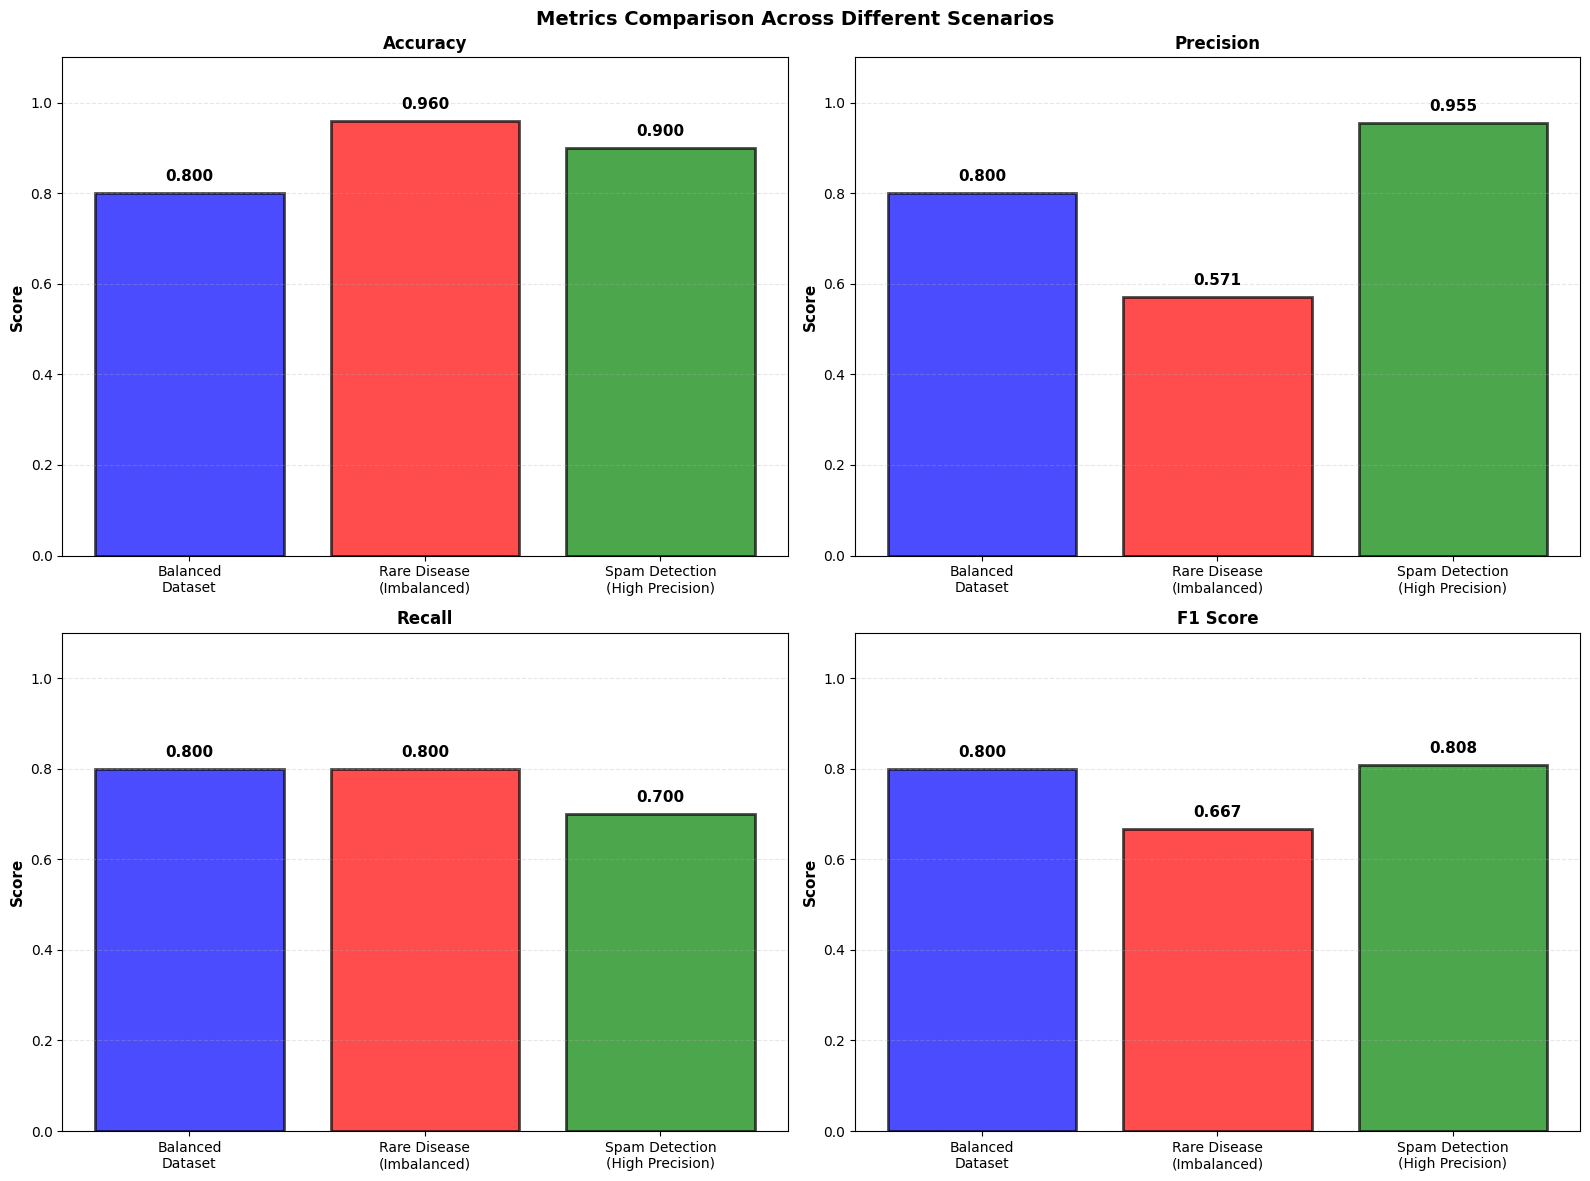


Key Observations:
1. Balanced dataset: All metrics are relatively similar
2. Rare disease: High accuracy but lower recall - accuracy is misleading!
3. Spam detection: Very high precision but moderate recall - by design


In [12]:
# Compare metrics across scenarios
scenarios = ['Balanced\nDataset', 'Rare Disease\n(Imbalanced)', 'Spam Detection\n(High Precision)']
metrics_list = [metrics_balanced, metrics_imbalanced, metrics_spam]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_funcs = [
    lambda m: m.accuracy(),
    lambda m: m.precision(),
    lambda m: m.recall(),
    lambda m: m.f1_score()
]

for idx, (name, func) in enumerate(zip(metric_names, metric_funcs)):
    ax = axes[idx // 2, idx % 2]
    values = [func(m) for m in metrics_list]
    
    bars = ax.bar(scenarios, values, color=['blue', 'red', 'green'], alpha=0.7, edgecolor='black', linewidth=2)
    
    # Add values on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
               f'{value:.3f}',
               ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Metrics Comparison Across Different Scenarios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. Balanced dataset: All metrics are relatively similar")
print("2. Rare disease: High accuracy but lower recall - accuracy is misleading!")
print("3. Spam detection: Very high precision but moderate recall - by design")

In [13]:
print("=" * 70)
print("MANUAL CALCULATION EXAMPLE")
print("=" * 70)

# Simple example
y_true_simple = torch.tensor([1, 1, 0, 0, 1, 0])
y_pred_simple = torch.tensor([1, 0, 0, 1, 1, 0])

print(f"\nTrue labels:      {y_true_simple.tolist()}")
print(f"Predicted labels: {y_pred_simple.tolist()}")

# Manual calculation
print("\n" + "=" * 70)
print("STEP-BY-STEP CALCULATION")
print("=" * 70)

# Count each case
print("\nAnalyzing each prediction:")
print(f"{'Index':<8} {'True':<8} {'Pred':<8} {'Result'}")
print("-" * 40)

tp_manual = 0
tn_manual = 0
fp_manual = 0
fn_manual = 0

for i in range(len(y_true_simple)):
    true_val = y_true_simple[i].item()
    pred_val = y_pred_simple[i].item()
    
    if true_val == 1 and pred_val == 1:
        result = "TP (True Positive)"
        tp_manual += 1
    elif true_val == 0 and pred_val == 0:
        result = "TN (True Negative)"
        tn_manual += 1
    elif true_val == 0 and pred_val == 1:
        result = "FP (False Positive)"
        fp_manual += 1
    else:  # true_val == 1 and pred_val == 0
        result = "FN (False Negative)"
        fn_manual += 1
    
    print(f"{i:<8} {true_val:<8} {pred_val:<8} {result}")

print(f"\n" + "-" * 70)
print("Confusion Matrix Components:")
print(f"  TP = {tp_manual}")
print(f"  TN = {tn_manual}")
print(f"  FP = {fp_manual}")
print(f"  FN = {fn_manual}")

# Calculate metrics manually
print(f"\n" + "-" * 70)
print("Calculating Metrics:")
print("-" * 70)

accuracy_manual = (tp_manual + tn_manual) / len(y_true_simple)
print(f"\nAccuracy = (TP + TN) / Total")
print(f"         = ({tp_manual} + {tn_manual}) / {len(y_true_simple)}")
print(f"         = {accuracy_manual:.4f}")

precision_manual = tp_manual / (tp_manual + fp_manual) if (tp_manual + fp_manual) > 0 else 0
print(f"\nPrecision = TP / (TP + FP)")
print(f"          = {tp_manual} / ({tp_manual} + {fp_manual})")
print(f"          = {precision_manual:.4f}")

recall_manual = tp_manual / (tp_manual + fn_manual) if (tp_manual + fn_manual) > 0 else 0
print(f"\nRecall = TP / (TP + FN)")
print(f"       = {tp_manual} / ({tp_manual} + {fn_manual})")
print(f"       = {recall_manual:.4f}")

f1_manual = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0
print(f"\nF1 Score = 2 * (Precision * Recall) / (Precision + Recall)")
print(f"         = 2 * ({precision_manual:.4f} * {recall_manual:.4f}) / ({precision_manual:.4f} + {recall_manual:.4f})")
print(f"         = {f1_manual:.4f}")

specificity_manual = tn_manual / (tn_manual + fp_manual) if (tn_manual + fp_manual) > 0 else 0
print(f"\nSpecificity = TN / (TN + FP)")
print(f"            = {tn_manual} / ({tn_manual} + {fp_manual})")
print(f"            = {specificity_manual:.4f}")

# Verify with our class
print(f"\n" + "=" * 70)
print("VERIFICATION WITH EvaluationMetrics CLASS")
print("=" * 70)

metrics_simple = EvaluationMetrics(y_true_simple, y_pred_simple)
print(f"\nAccuracy:    {metrics_simple.accuracy():.4f} (manual: {accuracy_manual:.4f})")
print(f"Precision:   {metrics_simple.precision():.4f} (manual: {precision_manual:.4f})")
print(f"Recall:      {metrics_simple.recall():.4f} (manual: {recall_manual:.4f})")
print(f"F1 Score:    {metrics_simple.f1_score():.4f} (manual: {f1_manual:.4f})")
print(f"Specificity: {metrics_simple.specificity():.4f} (manual: {specificity_manual:.4f})")
print("\n✓ All manual calculations match!")

MANUAL CALCULATION EXAMPLE

True labels:      [1, 1, 0, 0, 1, 0]
Predicted labels: [1, 0, 0, 1, 1, 0]

STEP-BY-STEP CALCULATION

Analyzing each prediction:
Index    True     Pred     Result
----------------------------------------
0        1        1        TP (True Positive)
1        1        0        FN (False Negative)
2        0        0        TN (True Negative)
3        0        1        FP (False Positive)
4        1        1        TP (True Positive)
5        0        0        TN (True Negative)

----------------------------------------------------------------------
Confusion Matrix Components:
  TP = 2
  TN = 2
  FP = 1
  FN = 1

----------------------------------------------------------------------
Calculating Metrics:
----------------------------------------------------------------------

Accuracy = (TP + TN) / Total
         = (2 + 2) / 6
         = 0.6667

Precision = TP / (TP + FP)
          = 2 / (2 + 1)
          = 0.6667

Recall = TP / (TP + FN)
       = 2 / (2 + 1)
  

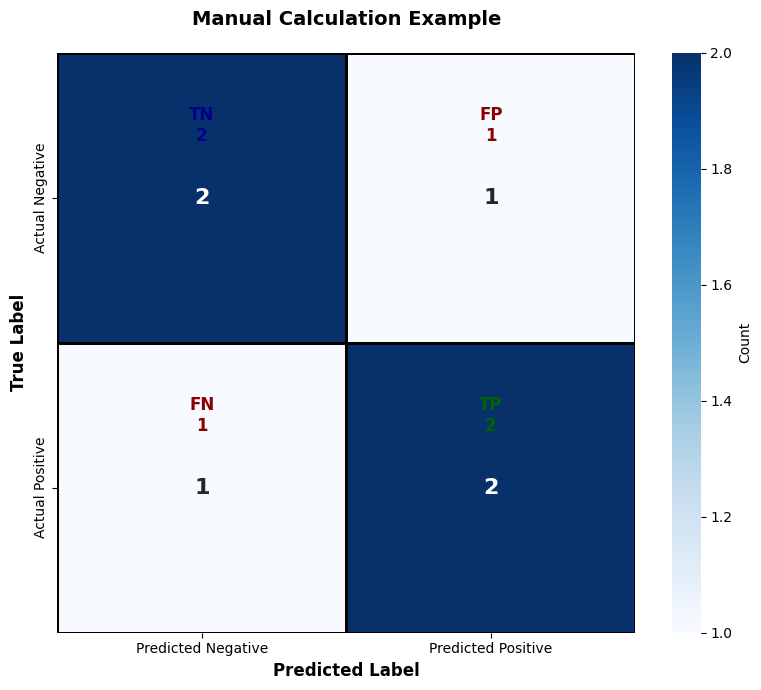

In [14]:
# Visualize simple example
metrics_simple.plot_confusion_matrix("Manual Calculation Example")